# Figure 1: Multi-Model CANDELS Galaxy SED Fit

Fits a single z~1 CANDELS galaxy under 4 model configurations spanning the
full modeling assumption space (SFH, SSP, dust law, nebular, AGN, metallicity).
Produces a 3-panel figure: (a) fitted SED, (b) inferred SFH, (c) M*-SFR corner.

In [11]:
from __future__ import annotations

import sys
import time
import warnings
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

# tengri imports
from tengri import Fitter, Fixed, Parameters, SEDModel, Uniform
from tengri.observation import Observation, Photometry
from tengri.sps import load_ssp_data
from tengri.utils.magnitudes import ab_mag_to_fnu

# Paths — works both as .py script and inside Jupyter
try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()  # Jupyter: assumes CWD is the notebook directory
DATA_DIR = NOTEBOOK_DIR / "data"
FIG_DIR = NOTEBOOK_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent

# Add analysis dir to path for common.py
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))
from common import setup_matplotlib

setup_matplotlib()  # configures rcParams before plt is used

<module 'matplotlib.pyplot' from '/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py'>

## 1. Parse CANDELS Catalog

In [12]:
# --- Column mapping: catalog columns → tengri filter names ---
# Catalog structure: ID, zz, then 17 pairs of (mag, e_mag), then flg1, flg2
# Column indices are 0-based for the mag columns (skipping ID and zz)
FILTER_MAP = {
    # (mag_col_index, err_col_index, tengri_name)
    # Skipping CTIO_U (idx 2,3) and VIMOS_U (idx 4,5) — often non-detect at z~1
    "ACS_F435W": (6, 7, "hst_f435w"),
    "ACS_F606W": (8, 9, "hst_f606w"),
    "ACS_F775W": (10, 11, "hst_f775w"),
    "ACS_F814W": (12, 13, "hst_f814w"),
    "ACS_F850LP": (14, 15, "hst_f850lp"),
    # Skipping WFC3_F098M (idx 16,17) — not in tengri registry, F105W adjacent
    "WFC3_F105W": (18, 19, "hst_f105w"),
    "WFC3_F125W": (20, 21, "hst_f125w"),
    "WFC3_F160W": (22, 23, "hst_f160w"),
    "ISAAC_KS": (24, 25, "vista_ks"),  # proxy (similar Ks passband)
    # Skipping HAWKI_KS (idx 26,27) — duplicate Ks, use ISAAC only
    "IRAC_CH1": (28, 29, "irac_36"),
    "IRAC_CH2": (30, 31, "irac_45"),
    "IRAC_CH3": (32, 33, "irac_58"),
    "IRAC_CH4": (34, 35, "irac_80"),
}


def parse_candels_catalog(filepath):
    """Parse CANDELS workshop catalog (AB magnitudes).

    Returns
    -------
    ids : array of int
        Galaxy IDs.
    redshifts : array of float
        Spectroscopic/photometric redshifts.
    mags : array, shape (n_gal, n_filters)
        AB magnitudes for each filter in FILTER_MAP.
    mag_errs : array, shape (n_gal, n_filters)
        Magnitude uncertainties.
    flg1 : array
        Quality flag 1 (0 = good).
    filter_names : list of str
        Tengri filter names corresponding to columns.
    catalog_names : list of str
        Original catalog band names.
    """
    raw = np.loadtxt(filepath, dtype=str)
    ids = raw[:, 0].astype(int)
    redshifts = raw[:, 1].astype(float)
    flg1 = raw[:, -2].astype(int)

    catalog_names = list(FILTER_MAP.keys())
    filter_names = [v[2] for v in FILTER_MAP.values()]

    n_gal = len(ids)
    n_filt = len(FILTER_MAP)
    mags = np.full((n_gal, n_filt), np.nan)
    mag_errs = np.full((n_gal, n_filt), np.nan)

    for i, (_name, (mag_col, err_col, _)) in enumerate(FILTER_MAP.items()):
        mags[:, i] = raw[:, mag_col].astype(float)
        mag_errs[:, i] = raw[:, err_col].astype(float)

    return ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names


# Parse
cat_file = DATA_DIR / "CANDELS_GDSS_workshop_z1.dat"
ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names = parse_candels_catalog(cat_file)

# Parse flags file (galaxies with bad photometry in specific bands)
flags_file = DATA_DIR / "flags_z1.dat"
flagged_ids = set()
if flags_file.exists():
    with open(flags_file) as f:
        for line in f:
            line = line.strip()
            if line.startswith("#") or not line:
                continue
            parts = line.split()
            if len(parts) >= 2:
                flagged_ids.add(int(parts[0]))

print(f"Catalog: {len(ids)} galaxies, {len(filter_names)} filters")
print(f"Flagged galaxies: {len(flagged_ids)}")
print(f"Filters: {filter_names}")

Catalog: 371 galaxies, 13 filters
Flagged galaxies: 32
Filters: ['hst_f435w', 'hst_f606w', 'hst_f775w', 'hst_f814w', 'hst_f850lp', 'hst_f105w', 'hst_f125w', 'hst_f160w', 'vista_ks', 'irac_36', 'irac_45', 'irac_58', 'irac_80']


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_52147/1609354569.py:45: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  raw = np.loadtxt(filepath, dtype=str)


## 2. Unit Conversion & Galaxy Selection

In [13]:
NON_DETECT_THRESHOLD = 90.0  # mag > 90 means non-detection in this catalog


def mag_to_fnu_with_errors(mags, mag_errs):
    """Convert AB magnitudes + errors to f_nu (erg/s/cm^2/Hz) + errors.

    Parameters
    ----------
    mags : array
        AB magnitudes. Values > NON_DETECT_THRESHOLD are non-detections.
    mag_errs : array
        Magnitude uncertainties. Values < 0 flag non-detections.

    Returns
    -------
    fnu : array
        Flux density in erg/s/cm^2/Hz. NaN for non-detections.
    sigma_fnu : array
        1-sigma flux errors. NaN for non-detections.
    detected : boolean array
        True where we have a valid detection.
    """
    detected = (mags < NON_DETECT_THRESHOLD) & (mag_errs > 0)

    fnu = np.full_like(mags, np.nan, dtype=np.float64)
    sigma_fnu = np.full_like(mags, np.nan, dtype=np.float64)

    good = detected
    fnu[good] = np.array(ab_mag_to_fnu(jnp.array(mags[good])))
    # Error propagation: sigma_fnu = fnu * sigma_mag * ln(10) / 2.5
    sigma_fnu[good] = fnu[good] * mag_errs[good] * np.log(10) / 2.5

    return fnu, sigma_fnu, detected


# Convert entire catalog
fnu_all, sigma_all, detected_all = mag_to_fnu_with_errors(mags, mag_errs)
n_detected = detected_all.sum(axis=1)

# --- Galaxy selection ---
# Criteria: z~1, good flags, >=10 detected bands, star-forming
z_mask = (redshifts > 0.95) & (redshifts < 1.15)
flag_mask = np.array([gid not in flagged_ids for gid in ids]) & (flg1 == 0)
det_mask = n_detected >= 10

candidates = z_mask & flag_mask & det_mask

# Compute median S/N for candidates
median_snr = np.full(len(ids), 0.0)
for i in range(len(ids)):
    if detected_all[i].sum() > 0:
        snr_i = fnu_all[i, detected_all[i]] / sigma_all[i, detected_all[i]]
        median_snr[i] = np.median(snr_i)

# Sort candidates by S/N and pick a good one
cand_idx = np.where(candidates)[0]
cand_order = np.argsort(-median_snr[cand_idx])
top_candidates = cand_idx[cand_order[:10]]

print("\nTop 10 candidates (z~1, ≥10 bands, good flags):")
print(f"{'ID':>8s} {'z':>6s} {'N_det':>5s} {'med_SNR':>8s}")
for idx in top_candidates:
    print(f"{ids[idx]:8d} {redshifts[idx]:6.3f} {n_detected[idx]:5d} {median_snr[idx]:8.1f}")


Top 10 candidates (z~1, ≥10 bands, good flags):
      ID      z N_det  med_SNR
   17418  1.096    12    542.9
   24497  1.031    11    542.9
   16049  1.047    13    271.4
   18160  1.095    13    271.4
   13097  1.097    13    271.4
   16435  1.094    13    217.1
   16455  1.087    13    217.1
   15775  1.097    13    217.1
   13601  1.022    12    181.0
   16514  1.018    13    181.0


In [14]:
# CANDELS 4171: z=1.032, 11 bands, moderate SF galaxy
SELECTED_IDX = np.where(ids == 4171)[0][0]
GAL_ID = ids[SELECTED_IDX]
GAL_Z = redshifts[SELECTED_IDX]

# Extract photometry for selected galaxy
gal_fnu = fnu_all[SELECTED_IDX]
gal_sigma = sigma_all[SELECTED_IDX]
gal_detected = detected_all[SELECTED_IDX]

# Build arrays for fitting (detected bands only)
fit_filter_names = [filter_names[i] for i in range(len(filter_names)) if gal_detected[i]]
fit_fnu = jnp.array(gal_fnu[gal_detected])
fit_sigma = jnp.array(gal_sigma[gal_detected])

print(f"\nSelected galaxy: ID={GAL_ID}, z={GAL_Z:.4f}")
print(f"Detected bands ({len(fit_filter_names)}):")
for i, (fname, cname) in enumerate(
    zip(fit_filter_names, [catalog_names[j] for j in range(len(catalog_names)) if gal_detected[j]])
):
    idx_orig = [k for k in range(len(filter_names)) if gal_detected[k]][i]
    print(
        f"  {cname:15s} → {fname:15s}  "
        f"mag={mags[SELECTED_IDX, idx_orig]:6.2f}  "
        f"fnu={gal_fnu[idx_orig]:.3e} ± {gal_sigma[idx_orig]:.3e}"
    )


Selected galaxy: ID=4171, z=1.0320
Detected bands (11):
  ACS_F435W       → hst_f435w        mag= 23.84  fnu=1.058e-29 ± 4.287e-31
  ACS_F606W       → hst_f606w        mag= 23.20  fnu=1.902e-29 ± 1.401e-31
  ACS_F775W       → hst_f775w        mag= 22.49  fnu=3.668e-29 ± 2.027e-31
  ACS_F814W       → hst_f814w        mag= 22.23  fnu=4.656e-29 ± 1.115e-30
  ACS_F850LP      → hst_f850lp       mag= 21.87  fnu=6.505e-29 ± 2.396e-31
  WFC3_F125W      → hst_f125w        mag= 21.28  fnu=1.116e-28 ± 6.167e-31
  WFC3_F160W      → hst_f160w        mag= 21.00  fnu=1.452e-28 ± 8.025e-31
  IRAC_CH1        → irac_36          mag= 19.89  fnu=4.003e-28 ± 7.374e-31
  IRAC_CH2        → irac_45          mag= 20.11  fnu=3.290e-28 ± 1.212e-30
  IRAC_CH3        → irac_58          mag= 20.40  fnu=2.519e-28 ± 6.728e-30
  IRAC_CH4        → irac_80          mag= 20.45  fnu=2.410e-28 ± 6.659e-30


## 3. Build Observation & Load SSP Data

In [15]:
# Build observation config
obs = Observation(photometry=Photometry.from_names(fit_filter_names))

# Load SSP data for each config (4 different libraries)
print("Loading SSP data...")
t0 = time.time()
ssp_mist = load_ssp_data(
    str(PROJECT_ROOT / "data" / "ssp_mist_c3k_a_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
)
ssp_padova = load_ssp_data(
    str(PROJECT_ROOT / "data" / "ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
)
ssp_bc03 = load_ssp_data(str(PROJECT_ROOT / "data" / "bc03_pdva_stelib_chabrier.h5"))
ssp_bpass = load_ssp_data(str(PROJECT_ROOT / "data" / "bpss_stars_c3k_a_chabrier.h5"))
print(f"SSP data loaded in {time.time() - t0:.1f}s")

Loading SSP data...
SSP data loaded in 0.1s


## 4. Define 4 Model Configurations

All parametric SFHs, all NUTS. Varies SFH family, SSP library, dust law,
nebular treatment, and metallicity handling.
4 configs spanning: SFH type, SSP, dust law, dust emission, nebular, AGN.
Two use dense_basis (distinguished by dust emission + AGN + SSP).

| Config | SFH | SSP | Dust atten. | Dust emis. | Neb. | AGN |
|--------|-----|-----|-------------|------------|------|-----|
| A | dense_basis | MIST | Salim | DL07 | neb. | off |
| B | dense_basis | Padova | Calzetti | off | neb. | off |
| C | tsnorm | BC03 | K&C | off | off | off |
| D | DPL | BPASS | power-law | off | off | off |

In [16]:
# Shared dense_basis SFH priors
DB_SFH = dict(
    sfh_db_log_total_mass=Uniform(8.0, 12.5),
    sfh_db_log_sfr_inst=Uniform(-2.0, 3.0),
    sfh_db_tx_frac_0=Uniform(0.05, 0.95),
    sfh_db_tx_frac_1=Uniform(0.05, 0.95),
    sfh_db_tx_frac_2=Uniform(0.05, 0.95),
)
DUST_PRIORS = dict(
    dust_tau_bc=Uniform(0.0, 3.0),
    dust_tau_diff=Uniform(0.0, 2.0),
)

# ---- Config A: dense_basis / MIST / Salim / neb ----
params_a = Parameters(
    mean_sfh_type="dense_basis",
    dust_law_bc="salim_sbl18",
    dust_model="two_component",
    nebular_ssp=True,
    met_logzsol=Uniform(-2.0, 0.3),
    apply_igm=True,
    redshift=Fixed(GAL_Z),
    **DB_SFH,
    **DUST_PRIORS,
)

# ---- Config B: dense_basis / Padova / Calzetti / no dust emis. / neb ----
params_b = Parameters(
    mean_sfh_type="dense_basis",
    dust_law_bc="calzetti",
    dust_model="two_component",
    nebular_ssp=True,
    met_logzsol=Uniform(-2.0, 0.3),
    apply_igm=True,
    redshift=Fixed(GAL_Z),
    **DB_SFH,
    **DUST_PRIORS,
)

# ---- Config C: tsnorm / BC03 / Kriek & Conroy / no neb ----
params_c = Parameters(
    mean_sfh_type="tsnorm",
    dust_law_bc="kriek_conroy",
    dust_model="two_component",
    apply_igm=True,
    redshift=Fixed(GAL_Z),
    met_logzsol=Uniform(-2.0, 0.3),
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.2, 5.0),
    sfh_tsnorm_skew=Uniform(-1.0, 1.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    **DUST_PRIORS,
)

# ---- Config D: DPL / BPASS / power-law / no neb / fixed Z ----
params_d = Parameters(
    mean_sfh_type="dpl",
    dust_law_bc="power_law",
    dust_model="two_component",
    apply_igm=True,
    redshift=Fixed(GAL_Z),
    met_logzsol=Fixed(-0.3),
    sfh_dpl_alpha=Uniform(0.5, 5.0),
    sfh_dpl_beta=Uniform(0.3, 3.0),
    sfh_dpl_tau_gyr=Uniform(0.5, 13.0),
    sfh_dpl_log_peak_sfr=Uniform(-1.0, 2.5),
    **DUST_PRIORS,
)

# Bundle configs
CONFIGS = {
    "A: DB+Salim": (params_a, ssp_mist),
    "B: DB+Calz": (params_b, ssp_padova),
    "C: tsnorm": (params_c, ssp_bc03),
    "D: DPL": (params_d, ssp_bpass),
}

for name, (params, _) in CONFIGS.items():
    n_free = len(params.free_params)
    print(f"{name:30s}  D={n_free:3d}  method=nss")

A: DB+Salim                     D=  8  method=nss
B: DB+Calz                      D=  8  method=nss
C: tsnorm                       D=  8  method=nss
D: DPL                          D=  6  method=nss


## 5. Run Inference

In [17]:
# NSS (Nested Slice Sampling) — gives log-evidence for proper BMA weighting.
# Reduced n_live=200 to keep memory low for D~5-10 parametric models.
results = {}  # config_name -> Posterior

for name, (params, ssp) in CONFIGS.items():
    print(f"\n{'=' * 60}")
    print(f"Fitting: {name} (NSS)")
    print(f"{'=' * 60}")

    model = SEDModel(params, ssp, observation=obs)
    fitter = Fitter(model, data=fit_fnu, noise=fit_sigma)

    t0 = time.time()
    key = jax.random.PRNGKey(abs(hash(name)) % (2**31))
    posterior = fitter.run(
        "nss",
        key=key,
        n_live=500,
        n_posterior_samples=1000,
        verbose=True,
    )
    t_inf = time.time() - t0

    log_z = posterior.log_evidence
    print(f"  NSS: {t_inf:.1f}s  log Z = {log_z:.1f}")

    results[name] = posterior

print("\nAll fits complete.")


Fitting: A: DB+Salim (NSS)


/Users/suchethacooray/Projects/tengri/src/tengri/forward/sed_model.py:657: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your ParamSpec will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = BakedInBackend()
assuming the specified inverse covariance is diagonal
assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


NSS: 8 parameters, 500 live points, 50 deletions/iter, 8 HRSS steps


/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)
W0416 02:59:31.794261 11396222 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  NSS iter 10: log Z ≈ -2703.54, n_dead=500, elapsed=28.4s
  NSS iter 20: log Z ≈ -2704.59, n_dead=1000, elapsed=28.8s
  NSS iter 30: log Z ≈ -1759.13, n_dead=1500, elapsed=29.2s
  NSS iter 40: log Z ≈ -1259.86, n_dead=2000, elapsed=29.7s
  NSS iter 50: log Z ≈ -1260.91, n_dead=2500, elapsed=30.1s
  NSS iter 60: log Z ≈ -1084.33, n_dead=3000, elapsed=30.7s
  NSS iter 70: log Z ≈ -839.50, n_dead=3500, elapsed=31.2s
  NSS iter 80: log Z ≈ -512.48, n_dead=4000, elapsed=31.6s
  NSS iter 90: log Z ≈ -401.33, n_dead=4500, elapsed=32.1s
  NSS iter 100: log Z ≈ -362.05, n_dead=5000, elapsed=32.6s
  NSS iter 110: log Z ≈ -282.77, n_dead=5500, elapsed=33.1s
  NSS iter 120: log Z ≈ -283.82, n_dead=6000, elapsed=33.7s
  NSS iter 130: log Z ≈ -276.37, n_dead=6500, elapsed=34.3s
  NSS iter 140: log Z ≈ -244.04, n_dead=7000, elapsed=34.8s
  NSS iter 150: log Z ≈ -236.32, n_dead=7500, elapsed=35.4s
  NSS iter 160: log Z ≈ -237.38, n_dead=8000, elapsed=36.0s
  NSS iter 170: log Z ≈ -231.37, n_dead=8500

...

NSS: 8 parameters, 500 live points, 50 deletions/iter, 8 HRSS steps
  NSS iter 10: log Z ≈ -5035.48, n_dead=500, elapsed=2.0s
  NSS iter 20: log Z ≈ -1250.31, n_dead=1000, elapsed=2.5s
  NSS iter 30: log Z ≈ -1251.36, n_dead=1500, elapsed=2.9s
  NSS iter 40: log Z ≈ -807.55, n_dead=2000, elapsed=3.3s
  NSS iter 50: log Z ≈ -808.60, n_dead=2500, elapsed=3.8s
  NSS iter 60: log Z ≈ -676.06, n_dead=3000, elapsed=4.3s
  NSS iter 70: log Z ≈ -306.61, n_dead=3500, elapsed=4.8s
  NSS iter 80: log Z ≈ -276.86, n_dead=4000, elapsed=5.4s
  NSS iter 90: log Z ≈ -180.96, n_dead=4500, elapsed=6.0s
  NSS iter 100: log Z ≈ -137.50, n_dead=5000, elapsed=6.6s
  NSS iter 110: log Z ≈ -138.55, n_dead=5500, elapsed=7.2s
  NSS iter 120: log Z ≈ -139.16, n_dead=6000, elapsed=7.8s
  NSS iter 130: log Z ≈ -124.88, n_dead=6500, elapsed=8.3s
  NSS iter 140: log Z ≈ -125.93, n_dead=7000, elapsed=8.9s
  NSS iter 150: log Z ≈ -124.97, n_dead=7500, elapsed=9.6s
  NSS iter 160: log Z ≈ -123.42, n_dead=8000, elapsed=

/Users/suchethacooray/Projects/tengri/src/tengri/forward/sed_model.py:661: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your ParamSpec will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = BakedInBackend()
assuming the specified inverse covariance is diagonal
assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


NSS: 8 parameters, 500 live points, 50 deletions/iter, 8 HRSS steps
  NSS iter 10: log Z ≈ -2343.82, n_dead=500, elapsed=1.9s
  NSS iter 20: log Z ≈ -2344.87, n_dead=1000, elapsed=2.3s
  NSS iter 30: log Z ≈ -1913.37, n_dead=1500, elapsed=2.6s
  NSS iter 40: log Z ≈ -1914.42, n_dead=2000, elapsed=3.0s
  NSS iter 50: log Z ≈ -1461.94, n_dead=2500, elapsed=3.3s
  NSS iter 60: log Z ≈ -1117.77, n_dead=3000, elapsed=3.7s
  NSS iter 70: log Z ≈ -769.36, n_dead=3500, elapsed=4.1s
  NSS iter 80: log Z ≈ -529.94, n_dead=4000, elapsed=4.4s
  NSS iter 90: log Z ≈ -530.99, n_dead=4500, elapsed=4.8s
  NSS iter 100: log Z ≈ -352.96, n_dead=5000, elapsed=5.2s
  NSS iter 110: log Z ≈ -354.01, n_dead=5500, elapsed=5.6s
  NSS iter 120: log Z ≈ -346.16, n_dead=6000, elapsed=5.9s
  NSS iter 130: log Z ≈ -328.28, n_dead=6500, elapsed=6.3s
  NSS iter 140: log Z ≈ -313.10, n_dead=7000, elapsed=6.7s
  NSS iter 150: log Z ≈ -266.40, n_dead=7500, elapsed=7.1s
  NSS iter 160: log Z ≈ -267.44, n_dead=8000, elaps

assuming the specified inverse covariance is diagonal
assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


  NSS complete in 14.3s. log Z = -240.56, ESS = 3842
  NSS: 19.6s  log Z = -240.6

Fitting: D: DPL (NSS)
NSS: 6 parameters, 500 live points, 50 deletions/iter, 6 HRSS steps
  NSS iter 10: log Z ≈ -4394.30, n_dead=500, elapsed=2.4s
  NSS iter 20: log Z ≈ -3205.29, n_dead=1000, elapsed=3.9s
  NSS iter 30: log Z ≈ -1742.09, n_dead=1500, elapsed=30.6s
  NSS iter 40: log Z ≈ -1355.81, n_dead=2000, elapsed=30.8s
  NSS iter 50: log Z ≈ -1356.86, n_dead=2500, elapsed=30.9s
  NSS iter 60: log Z ≈ -1357.91, n_dead=3000, elapsed=31.0s
  NSS iter 70: log Z ≈ -1068.66, n_dead=3500, elapsed=31.2s
  NSS iter 80: log Z ≈ -1069.70, n_dead=4000, elapsed=31.3s
  NSS iter 90: log Z ≈ -801.73, n_dead=4500, elapsed=31.4s
  NSS iter 100: log Z ≈ -802.79, n_dead=5000, elapsed=31.5s
  NSS iter 110: log Z ≈ -683.96, n_dead=5500, elapsed=31.7s
  NSS iter 120: log Z ≈ -685.01, n_dead=6000, elapsed=31.8s
  NSS iter 130: log Z ≈ -603.99, n_dead=6500, elapsed=31.9s
  NSS iter 140: log Z ≈ -579.88, n_dead=7000, elaps

## 6. Extract Posterior Predictions

In [18]:
N_DRAWS = 150  # posterior draws for SED + SFH bands
N_SFH_DRAWS = 80  # SFH draws (slower — predict_sfh not JIT'd)

# Wavelength grid for full-spectrum SED plots
WAVE_SPEC = np.logspace(np.log10(3000), np.log10(1e5), 300)  # 3000-100000 Å

# Storage
spec_draws = {}  # config -> (n_draws, n_wave) flux array
phot_draws = {}  # config -> (n_draws, n_filt) photometric flux array
sfh_draws = {}  # config -> dict with t_gyr, sfr array
prop_draws = {}  # config -> dict with log_mass, log_sfr arrays

for name, posterior in results.items():
    params_cfg, ssp = CONFIGS[name]
    model = SEDModel(params_cfg, ssp, observation=obs)

    samples = posterior.samples
    n_avail = next(iter(samples.values())).shape[0]
    n_use = min(N_DRAWS, n_avail)

    # Full-spectrum SED predictions
    spec_arr, phot_arr = [], []
    for i in range(n_use):
        s_i = {k: v[i] for k, v in samples.items()}
        spec_i = model.predict_spectrum(s_i, wave_obs=jnp.array(WAVE_SPEC))
        phot_i = model.predict_photometry(s_i)
        spec_arr.append(np.array(spec_i))
        phot_arr.append(np.array(phot_i))
    spec_draws[name] = np.array(spec_arr)
    phot_draws[name] = np.array(phot_arr)

    # SFH predictions
    sfr_arr = []
    t_gyr = None
    for i in range(min(n_use, N_SFH_DRAWS)):
        s_i = {k: v[i] for k, v in samples.items()}
        sfh_i = model.predict_sfh(s_i)
        if t_gyr is None:
            t_gyr = np.array(sfh_i["t_gyr"])
        sfr_arr.append(np.array(sfh_i["sfr_full"]))
    sfh_draws[name] = {"t_gyr": t_gyr, "sfr": np.array(sfr_arr)}

    # Derived quantities (M*, SFR)
    # Apply approximate return fraction correction: surviving ≈ 0.6 × formed
    # (Chabrier IMF, typical ages 1-10 Gyr; Conroy+2009, Madau & Dickinson 2014)
    RETURN_FRAC = 0.6  # M_surviving / M_formed
    mass_arr, sfr_arr_q = [], []
    for i in range(n_use):
        s_i = {k: v[i] for k, v in samples.items()}
        q = model.predict_sfh_quantities(s_i)
        mass_arr.append(float(q.stellar_mass) * RETURN_FRAC)
        sfr_arr_q.append(float(q.sfr_100myr))
    log_mass = np.log10(np.array(mass_arr))
    log_sfr = np.log10(np.maximum(np.array(sfr_arr_q), 1e-10))
    prop_draws[name] = {"log_mass": log_mass, "log_sfr": log_sfr}

    print(
        f"{name:30s}  "
        f"log M*={np.median(log_mass):.2f} ± {np.std(log_mass):.2f}  "
        f"log SFR={np.median(log_sfr):.2f} ± {np.std(log_sfr):.2f}"
    )

A: DB+Salim                     log M*=10.97 ± 0.02  log SFR=1.48 ± 0.01
B: DB+Calz                      log M*=11.01 ± 0.02  log SFR=1.52 ± 0.02
C: tsnorm                       log M*=10.61 ± 0.02  log SFR=1.56 ± 0.02
D: DPL                          log M*=10.54 ± 0.02  log SFR=1.65 ± 0.01


## 7. Create 3-Panel Figure (APJ style)

In [19]:
import scienceplots  # noqa: F401

plt.style.use(["science", "nature"])
plt.rcParams.update(
    {
        "font.size": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 5.5,
        "figure.dpi": 300,
        "savefig.dpi": 400,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.minor.width": 0.3,
        "ytick.minor.width": 0.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    }
)

# --- Color palette (Dark2 — colorblind-safe, print-friendly) ---
COLORS = {
    "A: DB+Salim": "#1b9e77",  # teal
    "B: DB+Calz": "#d95f02",  # deep orange
    "C: tsnorm": "#7570b3",  # muted purple
    "D: DPL": "#e7298a",  # magenta-pink
}
BMA_COLOR = "0.1"

SHORT_LABELS = {
    "A: DB+Salim": "Dense Basis / MIST / Salim / neb.",
    "B: DB+Calz": "Dense Basis / Padova / Calzetti",
    "C: tsnorm": r"Trunc. Skew-Normal / BC03 / K\&C",
    "D: DPL": "Double Power Law / BPASS / power-law",
}

# Effective wavelengths (Angstrom)
WAVE_EFF = {
    "hst_f435w": 4328,
    "hst_f606w": 5921,
    "hst_f775w": 7693,
    "hst_f814w": 8057,
    "hst_f850lp": 9036,
    "hst_f105w": 10552,
    "hst_f125w": 12486,
    "hst_f160w": 15369,
    "vista_ks": 21440,
    "irac_36": 35634,
    "irac_45": 45110,
    "irac_58": 57593,
    "irac_80": 79594,
}

BMA weights: {'A: DB+Salim': '0.000', 'B: DB+Calz': '1.000', 'C: tsnorm': '0.000', 'D: DPL': '0.000'}


/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)



Figure saved to /Users/suchethacooray/Projects/tengri/analysis/hst_proposal/figures/fig01_multimodel_candels.pdf


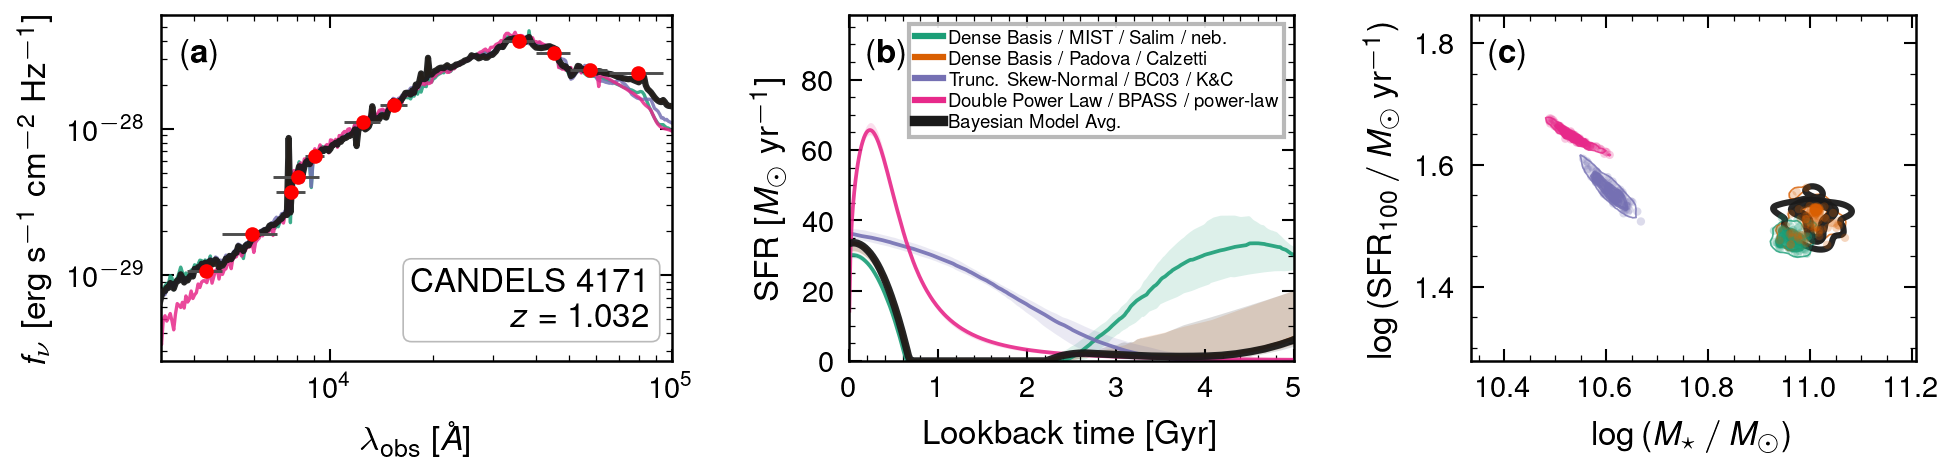

In [26]:
fig = plt.figure(figsize=(6.5, 1.65))  # compact for proposal
gs = GridSpec(
    1,
    3,
    figure=fig,
    width_ratios=[1.15, 1.0, 1.0],
    wspace=0.38,
    left=0.08,
    right=0.98,
    bottom=0.18,
    top=0.88,
)

# ======================================================================
# Panel (a): Full-spectrum SED + photometric data
# ======================================================================
ax_sed = fig.add_subplot(gs[0])

# Compute BMA weights (used by all panels)
log_evidences = np.array([results[n].log_evidence for n in CONFIGS])
log_w = log_evidences - log_evidences.max()
bma_weights = np.exp(log_w) / np.exp(log_w).sum()
print("BMA weights:", {n: f"{w:.3f}" for n, w in zip(CONFIGS, bma_weights)})

# Posterior spectral bands (full SED) for each config
for name in CONFIGS:
    color = COLORS[name]
    draws = spec_draws[name]
    med = np.median(draws, axis=0)
    lo = np.percentile(draws, 16, axis=0)
    hi = np.percentile(draws, 84, axis=0)
    ax_sed.fill_between(WAVE_SPEC, lo, hi, alpha=0.12, color=color, lw=0)
    ax_sed.plot(WAVE_SPEC, med, "-", color=color, lw=0.8, alpha=0.85)

# BMA posterior predictive spectrum (evidence-weighted draws from all configs)
bma_spec_all = []
for name, w in zip(CONFIGS, bma_weights):
    draws = spec_draws[name]
    n_take = max(5, round(w * 300))
    idx = np.random.choice(len(draws), size=min(n_take, len(draws)), replace=True)
    bma_spec_all.append(draws[idx])
bma_spec = np.concatenate(bma_spec_all, axis=0)
bma_spec_med = np.median(bma_spec, axis=0)
bma_spec_lo = np.percentile(bma_spec, 16, axis=0)
bma_spec_hi = np.percentile(bma_spec, 84, axis=0)
ax_sed.fill_between(WAVE_SPEC, bma_spec_lo, bma_spec_hi, alpha=0.10, color=BMA_COLOR, lw=0)
ax_sed.plot(WAVE_SPEC, bma_spec_med, "-", color=BMA_COLOR, lw=1.5, alpha=0.95, zorder=5)

# Observed photometry with error bars (on top)
wave_obs = np.array([WAVE_EFF[fn] for fn in fit_filter_names])
fnu_obs = np.array(fit_fnu)
sigma_obs = np.array(fit_sigma)
# Approximate filter half-widths (Angstrom) for xerr
FILTER_HALFWIDTH = {
    "hst_f435w": 500,
    "hst_f606w": 1100,
    "hst_f775w": 750,
    "hst_f814w": 1250,
    "hst_f850lp": 600,
    "hst_f105w": 1500,
    "hst_f125w": 1500,
    "hst_f160w": 1400,
    "vista_ks": 1600,
    "irac_36": 3800,
    "irac_45": 5100,
    "irac_58": 7100,
    "irac_80": 14300,
}
xerr_obs = np.array([FILTER_HALFWIDTH.get(fn, 500) for fn in fit_filter_names])

ax_sed.errorbar(
    wave_obs,
    fnu_obs,
    yerr=sigma_obs,
    xerr=xerr_obs,
    fmt="o",
    ms=3.5,
    color="r",
    ecolor="0.3",
    elinewidth=0.7,
    capsize=0,
    zorder=10,
    markeredgewidth=0,
)

ax_sed.set_xscale("log")
ax_sed.set_yscale("log")
ax_sed.set_xlabel(r"$\lambda_\mathrm{obs}$ [$\AA$]")
ax_sed.set_ylabel(r"$f_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax_sed.set_xlim(3200, 1e5)
ax_sed.text(0.04, 0.93, r"$\bf{(a)}$", transform=ax_sed.transAxes, fontsize=8, va="top")

# Galaxy ID annotation
ax_sed.text(
    0.96,
    0.08,
    f"CANDELS {GAL_ID}\n$z = {GAL_Z:.3f}$",
    transform=ax_sed.transAxes,
    fontsize=8,
    ha="right",
    va="bottom",
    bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "0.7", "lw": 0.4, "alpha": 0.9},
)

# ======================================================================
# Panel (b): Inferred SFH (linear y-scale, lookback=0 on left)
# ======================================================================
ax_sfh = fig.add_subplot(gs[1])

for name in CONFIGS:
    color = COLORS[name]
    t_gyr = sfh_draws[name]["t_gyr"]
    sfr = sfh_draws[name]["sfr"]
    med = np.median(sfr, axis=0)
    lo = np.percentile(sfr, 16, axis=0)
    hi = np.percentile(sfr, 84, axis=0)

    ax_sfh.fill_between(t_gyr, lo, hi, alpha=0.15, color=color, lw=0)
    ax_sfh.plot(t_gyr, med, "-", color=color, lw=0.9, alpha=0.9)

# BMA-averaged SFH (evidence-weighted, bma_weights computed above)
t_gyr_common = sfh_draws[next(iter(CONFIGS.keys()))]["t_gyr"]
bma_sfh_all = []
for name, w in zip(CONFIGS, bma_weights):
    sfr = sfh_draws[name]["sfr"]
    n_take = max(5, round(w * 200))
    idx = np.random.choice(len(sfr), size=min(n_take, len(sfr)), replace=True)
    bma_sfh_all.append(sfr[idx])
bma_sfr_arr = np.concatenate(bma_sfh_all, axis=0)
bma_med = np.median(bma_sfr_arr, axis=0)
bma_lo = np.percentile(bma_sfr_arr, 16, axis=0)
bma_hi = np.percentile(bma_sfr_arr, 84, axis=0)
ax_sfh.fill_between(t_gyr_common, bma_lo, bma_hi, alpha=0.15, color=BMA_COLOR, lw=0)
ax_sfh.plot(t_gyr_common, bma_med, "-", color=BMA_COLOR, lw=1.8, alpha=0.95)

ax_sfh.set_xlabel("Lookback time [Gyr]")
ax_sfh.set_ylabel(r"SFR [$M_\odot$ yr$^{-1}$]")
ax_sfh.set_xlim(0, 5)
ax_sfh.set_ylim(0, None)
# Auto-clip SFH ylim to 1.5x the max median (ignore spikes)
sfh_maxes = []
for name in CONFIGS:
    med = np.median(sfh_draws[name]["sfr"], axis=0)
    t = sfh_draws[name]["t_gyr"]
    sfh_maxes.append(np.max(med[t < 5]))
ax_sfh.set_ylim(0, 1.5 * max(sfh_maxes))
ax_sfh.text(0.04, 0.93, r"$\bf{(b)}$", transform=ax_sfh.transAxes, fontsize=8, va="top")

# ======================================================================
# Panel (c): M*-SFR posterior (scatter + contours)
# ======================================================================
ax_corner = fig.add_subplot(gs[2])

# Plot each config
for name in CONFIGS:
    color = COLORS[name]
    mass = prop_draws[name]["log_mass"]
    sfr = prop_draws[name]["log_sfr"]
    good = np.isfinite(mass) & np.isfinite(sfr)
    mass, sfr = mass[good], sfr[good]
    if len(mass) < 5:
        continue

    m_std, s_std = np.std(mass), np.std(sfr)
    if m_std < 1e-6 or s_std < 1e-6:
        ax_corner.plot(
            np.median(mass), np.median(sfr), "o", color=color, ms=5, alpha=0.9, zorder=5
        )
    else:
        # Scatter with transparency
        ax_corner.scatter(mass, sfr, s=4, color=color, alpha=0.25, edgecolors="none", zorder=3)
        # Try contours
        try:
            kde = gaussian_kde(np.vstack([mass, sfr]))
            pad_m = max(0.2, 3.5 * m_std)
            pad_s = max(0.2, 3.5 * s_std)
            mg = np.linspace(mass.mean() - pad_m, mass.mean() + pad_m, 60)
            sg = np.linspace(sfr.mean() - pad_s, sfr.mean() + pad_s, 60)
            MG, SG = np.meshgrid(mg, sg)
            ZG = kde(np.vstack([MG.ravel(), SG.ravel()])).reshape(MG.shape)
            Z_sorted = np.sort(ZG.ravel())[::-1]
            z_total = Z_sorted.sum()
            if z_total > 0:
                Z_cumsum = np.cumsum(Z_sorted) / z_total
                l68 = Z_sorted[np.searchsorted(Z_cumsum, 0.68)]
                l95 = Z_sorted[np.searchsorted(Z_cumsum, 0.95)]
                if l95 < l68:
                    ax_corner.contour(
                        MG,
                        SG,
                        ZG,
                        levels=[l95, l68],
                        colors=[color],
                        linewidths=[0.4, 0.8],
                        alpha=0.8,
                    )
        except (np.linalg.LinAlgError, ValueError):
            pass

# BMA contour in panel (c) — evidence-weighted
bma_m_all = np.concatenate(
    [
        np.random.choice(
            prop_draws[n]["log_mass"][np.isfinite(prop_draws[n]["log_mass"])],
            size=max(10, round(w * 2000)),
            replace=True,
        )
        for n, w in zip(CONFIGS, bma_weights)
    ]
)
bma_s_all = np.concatenate(
    [
        np.random.choice(
            prop_draws[n]["log_sfr"][np.isfinite(prop_draws[n]["log_sfr"])],
            size=max(10, round(w * 2000)),
            replace=True,
        )
        for n, w in zip(CONFIGS, bma_weights)
    ]
)
try:
    kde_bma = gaussian_kde(np.vstack([bma_m_all, bma_s_all]))
    m_std_b, s_std_b = bma_m_all.std(), bma_s_all.std()
    mg_b = np.linspace(bma_m_all.mean() - 3.5 * m_std_b, bma_m_all.mean() + 3.5 * m_std_b, 80)
    sg_b = np.linspace(bma_s_all.mean() - 3.5 * s_std_b, bma_s_all.mean() + 3.5 * s_std_b, 80)
    MGB, SGB = np.meshgrid(mg_b, sg_b)
    ZGB = kde_bma(np.vstack([MGB.ravel(), SGB.ravel()])).reshape(MGB.shape)
    Z_s = np.sort(ZGB.ravel())[::-1]
    zt = Z_s.sum()
    if zt > 0:
        Zc = np.cumsum(Z_s) / zt
        l68b = Z_s[np.searchsorted(Zc, 0.68)]
        l95b = Z_s[np.searchsorted(Zc, 0.95)]
        if l95b < l68b:
            ax_corner.contour(
                MGB,
                SGB,
                ZGB,
                levels=[l95b, l68b],
                colors=[BMA_COLOR],
                linewidths=[1.5, 2.5],
                linestyles="-",
                alpha=0.95,
            )
except (np.linalg.LinAlgError, ValueError):
    pass

ax_corner.set_xlabel(r"$\log\,(M_\star\,/\,M_\odot)$")
ax_corner.set_ylabel(r"$\log\,(\mathrm{SFR}_{100}\,/\,M_\odot\,\mathrm{yr}^{-1})$")
ax_corner.text(0.04, 0.93, r"$\bf{(c)}$", transform=ax_corner.transAxes, fontsize=8, va="top")

# ======================================================================
# Legend — in SFH panel (b), upper-right
# ======================================================================
from matplotlib.lines import Line2D

handles = [Line2D([0], [0], color=COLORS[n], lw=1.5, label=SHORT_LABELS[n]) for n in CONFIGS]
handles.append(Line2D([0], [0], color=BMA_COLOR, lw=2.5, ls="-", label="Bayesian Model Avg."))

# Legend inside panel (b), upper-right
ax_sfh.legend(
    handles=handles,
    loc="upper right",
    fontsize=4.5,
    frameon=True,
    fancybox=False,
    edgecolor="0.7",
    framealpha=0.92,
    handlelength=1.5,
    handletextpad=0.3,
    borderpad=0.3,
    labelspacing=0.2,
)

# ======================================================================
# Save
# ======================================================================
fig.savefig(FIG_DIR / "fig01_multimodel_candels.pdf", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "fig01_multimodel_candels.png", dpi=200, bbox_inches="tight")
print(f"\nFigure saved to {FIG_DIR}/fig01_multimodel_candels.pdf")
plt.show()